#  Stance Classification

**Dataset:** SemEval 2016 Task 6  1,249 test documents · 5 targets  
*(Atheism, Climate Change, Feminist Movement, Hillary Clinton, Legalization of Abortion)*  
**Task:** 3-class stance classification (FAVOR / AGAINST / NONE)  
**Primary metric:** Macro-F1 (unweighted mean across all three classes)  
**Shot counts analysed:** 0 (= `task_definition`), 3, 6, 9, 12

---

### Research Questions
1. How does stance classification performance change as the number of in-context examples increases?
2. Do the gains from additional shots saturate, and if so, at what point for each model?
3. Do SLMs and LLMs behave differently as shot count increases?
4. Which stance classes benefit most from additional shots?
5. What proportion of test examples change prediction as shot count increases?
6. Which examples are corrected by more shots, and which are harmed by more shots?
7. Which examples remain unstable across shot counts and across models?
8. Are there examples that are difficult mainly for SLMs but not for LLMs?

---
## 1 · Setup

In [125]:
# ── Imports (reused from stance_results_team_analysis.ipynb) ──────────────
from pathlib import Path
import re
from itertools import combinations
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy import stats as scipy_stats
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.35,
})
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

In [126]:
# ── Paths & label constants ───────────────────────────────────────────────
RUNS_ROOT = Path('../data_out/semeval2016_task6_testdata_gold')
LABELS    = ['FAVOR', 'AGAINST', 'NONE']
RNG       = np.random.default_rng(42)

# ICL prompts: 0-shot is 'task_definition'; few-shot are named few_shot_N
# Note: 'task_definition' is treated as 0-shot throughout this notebook.
ICL_PROMPTS     = ['task_definition', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12']
ICL_SHOT_COUNTS = [0, 3, 6, 9, 12]
SHOT_MAP        = dict(zip(ICL_PROMPTS, ICL_SHOT_COUNTS))  # prompt -> n_shots

PROMPT_LABELS = {   # human-readable names for axis labels
    'task_definition': '0-shot',
    'few_shot_3':      '3-shot',
    'few_shot_6':      '6-shot',
    'few_shot_9':      '9-shot',
    'few_shot_12':     '12-shot',
}

# ── Model metadata (reused from stance_results_team_analysis.ipynb) ───────
MODEL_SIZES = {
    'Qwen3-1.7B':                    1.7,
    'phi-4-mini-instruct':           3.8,
    'Nemotron-Mini-4B-Instruct':     4.0,
    'Qwen3-4B':                      4.0,
    'Qwen3-4B-Instruct-2507':        4.0,
    'Llama-3.1-8B-Instruct':         8.0,
    'DeepSeek-R1-Distill-Llama-8B':  8.0,
    'Qwen3-8B':                      8.0,
    'DeepSeek-R1-Distill-Qwen-14B': 14.0,
    'Qwen3-14B':                    14.0,
    'phi-4':                        14.0,
    'DeepSeek-R1-Distill-Qwen-32B': 32.0,
    'Qwen3-32B':                    32.0,
    # gpt-5-mini: closed-source, size undisclosed
}

MODEL_FAMILY = {
    'Qwen3-1.7B':                   'Qwen3',
    'Qwen3-4B':                     'Qwen3',
    'Qwen3-4B-Instruct-2507':       'Qwen3',
    'Qwen3-8B':                     'Qwen3',
    'Qwen3-14B':                    'Qwen3',
    'Qwen3-32B':                    'Qwen3',
    'Llama-3.1-8B-Instruct':        'Llama',
    'DeepSeek-R1-Distill-Llama-8B': 'DeepSeek-R1',
    'DeepSeek-R1-Distill-Qwen-14B': 'DeepSeek-R1',
    'DeepSeek-R1-Distill-Qwen-32B': 'DeepSeek-R1',
    'Nemotron-Mini-4B-Instruct':    'Nemotron',
    'phi-4-mini-instruct':          'Phi',
    'phi-4':                        'Phi',
    'gpt-5-mini':                   'GPT-5',
}

FAMILY_COLORS = {
    'Qwen3':       '#4C78A8',
    'DeepSeek-R1': '#F58518',
    'Llama':       '#72B7B2',
    'Nemotron':    '#76B900',
    'Phi':         '#E45756',
    'GPT-5':       '#54A24B',
    'Other':       '#B279A2',
}

# SLM threshold: < 14 B parameters (closed-source counted as LLM)
SLM_THRESHOLD_B = 14.0

SEMEVAL_BASELINE = 0.69
F1_USABLE        = 0.55

In [127]:
# ── Helper functions (reused from stance_results_team_analysis.ipynb) ─────

def parse_run_folder(name: str):
    """Extract (model, prompt) from a results folder name."""
    m = re.match(r'.*semeval2016_task6_testdata_gold_(.+)_equal_(.+)$', name)
    return (m.group(1), m.group(2)) if m else None

def norm_label(x):
    """Normalise a raw predicted label to FAVOR / AGAINST / NONE (or NaN)."""
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    if 'FAVOR'   in s: return 'FAVOR'
    if 'AGAINST' in s: return 'AGAINST'
    if s in {'NONE', 'NEITHER', 'NEUTRAL'}: return 'NONE'
    return s

def model_sort_key(model):
    """Sort key: size (asc) → family → name.  Closed-source goes last."""
    return (MODEL_SIZES.get(model, 999), MODEL_FAMILY.get(model, 'zzz'), model)

def family_color(model):
    return FAMILY_COLORS.get(MODEL_FAMILY.get(model, 'Other'), '#888888')

def build_model_colors(models):
    """Return {model: hex_color} with distinct lightness shades per family."""
    import colorsys
    from collections import defaultdict

    family_members = defaultdict(list)
    for m in models:
        family_members[MODEL_FAMILY.get(m, 'Other')].append(m)

    result = {}
    for fam, members in family_members.items():
        base = FAMILY_COLORS.get(fam, '#888888')
        h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(base))
        n = len(members)
        if n == 1:
            result[members[0]] = base
        else:
            lums = np.linspace(0.28, 0.62, n)
            for m, lum in zip(members, lums):
                result[m] = mcolors.to_hex(colorsys.hls_to_rgb(h, lum, s))
    return result

def is_slm(model):
    """True if model has a known size below SLM_THRESHOLD_B."""
    size = MODEL_SIZES.get(model)
    return size is not None and size < SLM_THRESHOLD_B

def is_llm(model):
    """True if model is >= SLM_THRESHOLD_B or closed-source."""
    size = MODEL_SIZES.get(model)
    return size is None or size >= SLM_THRESHOLD_B

In [128]:
# ── Load results (ICL prompts only) ──────────────────────────────────────
# Adapted from stance_results_team_analysis.ipynb cell 4.
# The key change: we filter to ICL_PROMPTS only, and include 'content' for
# qualitative inspection in Section 8.

run_files = sorted(RUNS_ROOT.glob('*/document_assignments.csv'))
if not run_files:
    raise FileNotFoundError(f'No run files found under {RUNS_ROOT}')

system_frames = {}   # key: '{model} | {prompt}' → DataFrame
meta_rows     = []

for fp in run_files:
    parsed = parse_run_folder(fp.parent.name)
    if parsed is None:
        continue
    model, prompt = parsed

    # ── ICL filter: only keep the five ICL prompt conditions ──────────────
    if prompt not in ICL_PROMPTS:
        continue

    df = pd.read_csv(fp)
    needed = {'doc_id', 'original_stance', 'predicted_stance'}
    if needed - set(df.columns):
        continue

    cols = ['doc_id', 'original_stance', 'predicted_stance']
    if 'query'   in df.columns: cols.append('query')
    if 'content' in df.columns: cols.append('content')  # for qualitative section

    df = df[cols].copy()
    df['doc_id'] = df['doc_id'].astype(str)
    df['gold']   = df['original_stance'].map(norm_label)
    df['pred']   = df['predicted_stance'].map(norm_label)
    df['n_shots'] = SHOT_MAP[prompt]

    n_total     = len(df)
    n_parseable = df['pred'].isin(LABELS).sum()
    parse_fail  = 1.0 - n_parseable / n_total

    df = df[df['gold'].isin(LABELS) & df['pred'].isin(LABELS)].copy()

    system = f'{model} | {prompt}'
    system_frames[system] = df
    meta_rows.append({
        'system':     system,
        'model':      model,
        'prompt':     prompt,
        'n_shots':    SHOT_MAP[prompt],
        'family':     MODEL_FAMILY.get(model, 'Other'),
        'size_B':     MODEL_SIZES.get(model),
        'tier':       'SLM' if is_slm(model) else 'LLM',
        'parse_fail': round(parse_fail * 100, 2),
        'n_total':    n_total,
        'n_eval':     len(df),
    })

meta_df = pd.DataFrame(meta_rows).sort_values(['model', 'n_shots'])
print(f'Systems loaded : {len(system_frames)}')
print(f'Models         : {meta_df["model"].nunique()}')
print(f'Shot counts    : {sorted(meta_df["n_shots"].unique())}')
print()
print('Models with complete 0→12 coverage:')
counts = meta_df.groupby('model')['n_shots'].nunique()
print(counts[counts == 5].index.tolist())

Systems loaded : 65
Models         : 13
Shot counts    : [0, 3, 6, 9, 12]

Models with complete 0→12 coverage:
['DeepSeek-R1-Distill-Llama-8B', 'DeepSeek-R1-Distill-Qwen-14B', 'Llama-3.1-8B-Instruct', 'Nemotron-Mini-4B-Instruct', 'Qwen3-1.7B', 'Qwen3-14B', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'Qwen3-8B', 'gpt-5-mini', 'gpt-5.2', 'phi-4', 'phi-4-mini-instruct']


In [129]:
# ── Compute metrics for all (model, prompt) combinations ─────────────────
# Reused from stance_results_team_analysis.ipynb cell 5.

metric_rows = []
for _, m in meta_df.iterrows():
    d  = system_frames[m['system']]
    yt = d['gold'].values
    yp = d['pred'].values
    p, r, f, sup = precision_recall_fscore_support(yt, yp, labels=LABELS, zero_division=0)
    metric_rows.append({
        **m.to_dict(),
        'macro_f1':       f1_score(yt, yp, labels=LABELS, average='macro', zero_division=0),
        'accuracy':       accuracy_score(yt, yp),
        'p_FAVOR':   p[0], 'r_FAVOR':   r[0], 'f1_FAVOR':   f[0],
        'p_AGAINST': p[1], 'r_AGAINST': r[1], 'f1_AGAINST': f[1],
        'p_NONE':    p[2], 'r_NONE':    r[2], 'f1_NONE':    f[2],
        'support_FAVOR': sup[0], 'support_AGAINST': sup[1], 'support_NONE': sup[2],
    })

metrics = pd.DataFrame(metric_rows)
metrics['size_label'] = metrics['size_B'].apply(
    lambda x: f'{x:g}B' if pd.notna(x) else 'closed'
)

# ── Quick sanity table ────────────────────────────────────────────────────
overview = (
    metrics.groupby(['model', 'tier', 'size_B', 'size_label'], dropna=False)
    .agg(
        best_macro_f1 = ('macro_f1', 'max'),
        mean_macro_f1 = ('macro_f1', 'mean'),
        n_shots_tested = ('n_shots', 'nunique'),
    )
    .reset_index()
    .sort_values('size_B', na_position='last')
)
display(overview)

,model,tier,size_B,size_label,best_macro_f1,mean_macro_f1,n_shots_tested
4,Qwen3-1.7B,SLM,1.700,1.7B,0.385,0.344,5
12,phi-4-mini-instruct,SLM,3.800,3.8B,0.596,0.584,5
3,Nemotron-Mini-4B-Instruct,SLM,4.000,4B,0.633,0.579,5
6,Qwen3-4B,SLM,4.000,4B,0.651,0.639,5
7,Qwen3-4B-Instruct-2507,SLM,4.000,4B,0.671,0.652,5
0,DeepSeek-R1-Distill-Llama-8B,SLM,8.000,8B,0.580,0.548,5
2,Llama-3.1-8B-Instruct,SLM,8.000,8B,0.582,0.544,5
8,Qwen3-8B,SLM,8.000,8B,0.687,0.661,5
1,DeepSeek-R1-Distill-Qwen-14B,LLM,14.000,14B,0.662,0.640,5
5,Qwen3-14B,LLM,14.000,14B,0.638,0.621,5


---
## 2 · Performance vs Shot Count

**RQ1:** How does stance classification performance change as the number of in-context examples increases?

We plot macro-F1 vs shot count (0, 3, 6, 9, 12) for every model, then provide summary tables of per-class precision / recall / F1.

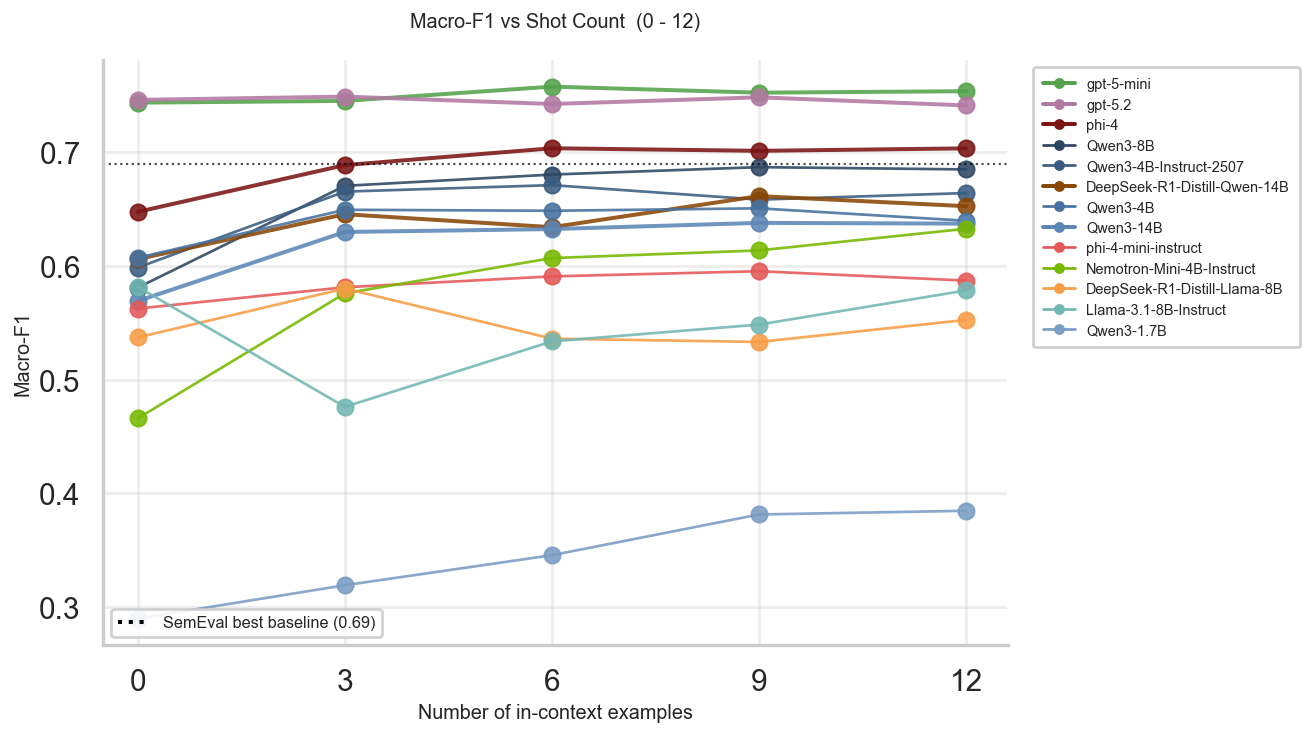

In [160]:
# ── Line chart: macro-F1 vs shot count (all models) ──────────────────────
# Adapted from stance_results_team_analysis.ipynb cell 12.

model_order = (
    metrics.groupby('model')['macro_f1'].mean()
    .sort_values(ascending=False).index.tolist()
)
model_colors = build_model_colors(model_order)

fig, ax = plt.subplots(figsize=(11, 6))

for model in model_order:
    sub   = metrics[metrics['model'] == model].sort_values('n_shots')
    color = model_colors.get(model, '#888888')
    size  = MODEL_SIZES.get(model)
    lw    = 2.2 if (size and size >= 14) or size is None else 1.5
    ls    = '-' if is_slm(model) else '-'
    ax.plot(sub['n_shots'], sub['macro_f1'], marker='o', color=color,
            linewidth=lw, linestyle=ls, alpha=0.88)

ax.axhline(SEMEVAL_BASELINE, color='#000',    linewidth=1.2, linestyle=':',  alpha=0.7)
ax.set_xticks(ICL_SHOT_COUNTS)
ax.set_xlim(-0.5, 12.6)
ax.set_xlabel('Number of in-context examples', fontsize=11)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title('Macro-F1 vs Shot Count  (0 - 12)\n', fontsize=11)

# \u2500\u2500 Reference lines legend (lower-left, inside plot) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ref_handles = [
   
    Line2D([0],[0], color='#000',    linestyle=':',
           label=f'SemEval best baseline ({SEMEVAL_BASELINE})'),
]
ref_leg = ax.legend(handles=ref_handles, fontsize=9, loc='lower left',
                    frameon=True, framealpha=0.9, edgecolor='#cccccc')
ax.add_artist(ref_leg)

# \u2500\u2500 Model legend (box on the right, outside axes) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
model_handles = [
    Line2D([0],[0],
           color=model_colors.get(m, '#888888'),
           marker='o', markersize=5,
           linewidth=2.2 if (MODEL_SIZES.get(m, 0) >= 14 or MODEL_SIZES.get(m) is None) else 1.5,
           linestyle='-' if is_llm(m) else '-',
           label=m)
    for m in model_order
]
ax.legend(handles=model_handles, fontsize=8,
          bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=True, framealpha=0.94, edgecolor='#cccccc',
          borderpad=0.7, labelspacing=0.45, handlelength=2.2)

plt.tight_layout()
plt.subplots_adjust(right=0.72)
plt.show()

In [131]:
# ── Summary table: macro-F1 at each shot count ────────────────────────────
pivot_f1 = (
    metrics
    .pivot_table(index='model', columns='n_shots', values='macro_f1', aggfunc='mean')
    .reindex(columns=ICL_SHOT_COUNTS)
)
pivot_f1.columns = [f'{c}-shot' for c in pivot_f1.columns]
pivot_f1['best'] = pivot_f1.max(axis=1)
pivot_f1 = pivot_f1.reindex(
    sorted(pivot_f1.index, key=model_sort_key)
).round(3)
display(pivot_f1)

,0-shot,3-shot,6-shot,9-shot,12-shot,best
model,,,,,,
Qwen3-1.7B,0.290,0.319,0.346,0.381,0.385,0.385
phi-4-mini-instruct,0.563,0.581,0.591,0.596,0.587,0.596
Nemotron-Mini-4B-Instruct,0.466,0.576,0.607,0.614,0.633,0.633
Qwen3-4B,0.607,0.650,0.649,0.651,0.640,0.651
Qwen3-4B-Instruct-2507,0.599,0.666,0.671,0.659,0.664,0.671
DeepSeek-R1-Distill-Llama-8B,0.537,0.580,0.536,0.533,0.553,0.580
Llama-3.1-8B-Instruct,0.582,0.476,0.534,0.549,0.579,0.582
Qwen3-8B,0.581,0.671,0.681,0.687,0.685,0.687
DeepSeek-R1-Distill-Qwen-14B,0.606,0.646,0.634,0.662,0.653,0.662


In [132]:
# ── Per-class P / R / F1 for each model at each shot count ───────────────
# Wide table: rows = (model, n_shots), cols = p/r/f1 per class
class_cols = (['p_FAVOR','r_FAVOR','f1_FAVOR',
               'p_AGAINST','r_AGAINST','f1_AGAINST',
               'p_NONE','r_NONE','f1_NONE'])
class_table = (
    metrics[['model','n_shots'] + class_cols]
    .sort_values(['model','n_shots'])
    .reset_index(drop=True)
    .round(3)
)
display(class_table)

,model,n_shots,p_FAVOR,r_FAVOR,f1_FAVOR,p_AGAINST,r_AGAINST,f1_AGAINST,p_NONE,r_NONE,f1_NONE
0,DeepSeek-R1-Distill-Llama-8B,0,0.615,0.605,0.610,0.882,0.388,0.539,0.315,0.870,0.463
1,DeepSeek-R1-Distill-Llama-8B,3,0.682,0.599,0.637,0.891,0.459,0.606,0.342,0.913,0.498
2,DeepSeek-R1-Distill-Llama-8B,6,0.656,0.484,0.557,0.882,0.438,0.585,0.313,0.913,0.467
3,DeepSeek-R1-Distill-Llama-8B,9,0.677,0.503,0.577,0.876,0.427,0.574,0.301,0.883,0.449
4,DeepSeek-R1-Distill-Llama-8B,12,0.703,0.536,0.608,0.900,0.428,0.580,0.315,0.926,0.470
...,...,...,...,...,...,...,...,...,...,...,...
60,phi-4-mini-instruct,0,0.628,0.523,0.571,0.790,0.516,0.624,0.353,0.813,0.493
61,phi-4-mini-instruct,3,0.498,0.694,0.580,0.775,0.628,0.694,0.455,0.487,0.471
62,phi-4-mini-instruct,6,0.528,0.661,0.587,0.751,0.676,0.711,0.480,0.470,0.475
63,phi-4-mini-instruct,9,0.568,0.632,0.598,0.758,0.702,0.729,0.442,0.478,0.459


---
## 3 · Saturation Analysis

**RQ2:** Do the gains from additional shots saturate, and if so, at what point for each model?

We compute step-by-step Δ macro-F1 (0→3, 3→6, 6→9, 9→12) and identify the best shot count per model.  
A gain is considered *saturated* when |Δ| < 0.01 for two consecutive steps.

In [133]:
# ── Step-by-step deltas per model ────────────────────────────────────────
# Adapted from stance_results_team_analysis.ipynb cell 13.

STEPS       = [(0,3), (3,6), (6,9), (9,12)]
STEP_LABELS = ['0→3', '3→6', '6→9', '9→12']
SATURATION_THRESHOLD = 0.01

step_rows = []
for model, grp in metrics.groupby('model'):
    grp = grp.sort_values('n_shots').set_index('n_shots')
    row = {
        'model':    model,
        'family':   MODEL_FAMILY.get(model, 'Other'),
        'size_B':   MODEL_SIZES.get(model),
        'tier':     'SLM' if is_slm(model) else 'LLM',
    }
    for (a, b), label in zip(STEPS, STEP_LABELS):
        if a in grp.index and b in grp.index:
            row[label] = round(grp.loc[b, 'macro_f1'] - grp.loc[a, 'macro_f1'], 4)
        else:
            row[label] = float('nan')
    if 0 in grp.index:
        row['f1_0shot']  = round(grp.loc[0, 'macro_f1'], 3)
    if 12 in grp.index:
        row['f1_12shot'] = round(grp.loc[12, 'macro_f1'], 3)
    row['best_shots'] = int(grp['macro_f1'].idxmax()) if len(grp) else np.nan
    step_rows.append(row)

step_df = (
    pd.DataFrame(step_rows)
    .sort_values('size_B', na_position='last')
    .reset_index(drop=True)
)

# ── Saturation summary ────────────────────────────────────────────────────
# Mark steps where absolute gain drops below threshold
def saturation_point(row):
    """Return shot count where gains plateau, or 12 if never saturated."""
    shot_seq = [0, 3, 6, 9, 12]
    for i, ((a, b), lbl) in enumerate(zip(STEPS, STEP_LABELS)):
        delta = row.get(lbl, np.nan)
        if pd.isna(delta):
            continue
        if abs(delta) < SATURATION_THRESHOLD:
            return a  # first step where gain < threshold
    return 12  # never saturated within range

step_df['saturation_at'] = step_df.apply(saturation_point, axis=1)
step_df['total_gain_0_12'] = (step_df['f1_12shot'] - step_df['f1_0shot']).round(3)

display(step_df[['model','tier','size_B',
                 'f1_0shot','f1_12shot','total_gain_0_12',
                 'best_shots','saturation_at'] + STEP_LABELS].round(4))

,model,tier,size_B,f1_0shot,f1_12shot,total_gain_0_12,best_shots,saturation_at,0→3,3→6,6→9,9→12
0,Qwen3-1.7B,SLM,1.700,0.290,0.385,0.095,12,9,0.029,0.026,0.036,0.003
1,phi-4-mini-instruct,SLM,3.800,0.563,0.587,0.024,9,3,0.019,0.010,0.004,-0.008
2,Nemotron-Mini-4B-Instruct,SLM,4.000,0.466,0.633,0.167,12,6,0.110,0.031,0.007,0.019
3,Qwen3-4B,SLM,4.000,0.607,0.640,0.033,9,3,0.042,-0.001,0.002,-0.011
4,Qwen3-4B-Instruct-2507,SLM,4.000,0.599,0.664,0.065,6,3,0.067,0.006,-0.013,0.006
5,DeepSeek-R1-Distill-Llama-8B,SLM,8.000,0.537,0.553,0.016,3,6,0.043,-0.044,-0.003,0.019
6,Llama-3.1-8B-Instruct,SLM,8.000,0.582,0.579,-0.003,0,12,-0.105,0.058,0.015,0.030
7,Qwen3-8B,SLM,8.000,0.581,0.685,0.104,9,3,0.089,0.010,0.006,-0.002
8,DeepSeek-R1-Distill-Qwen-14B,LLM,14.000,0.606,0.653,0.047,9,9,0.040,-0.011,0.027,-0.009
9,Qwen3-14B,LLM,14.000,0.569,0.637,0.068,9,3,0.061,0.003,0.005,-0.001


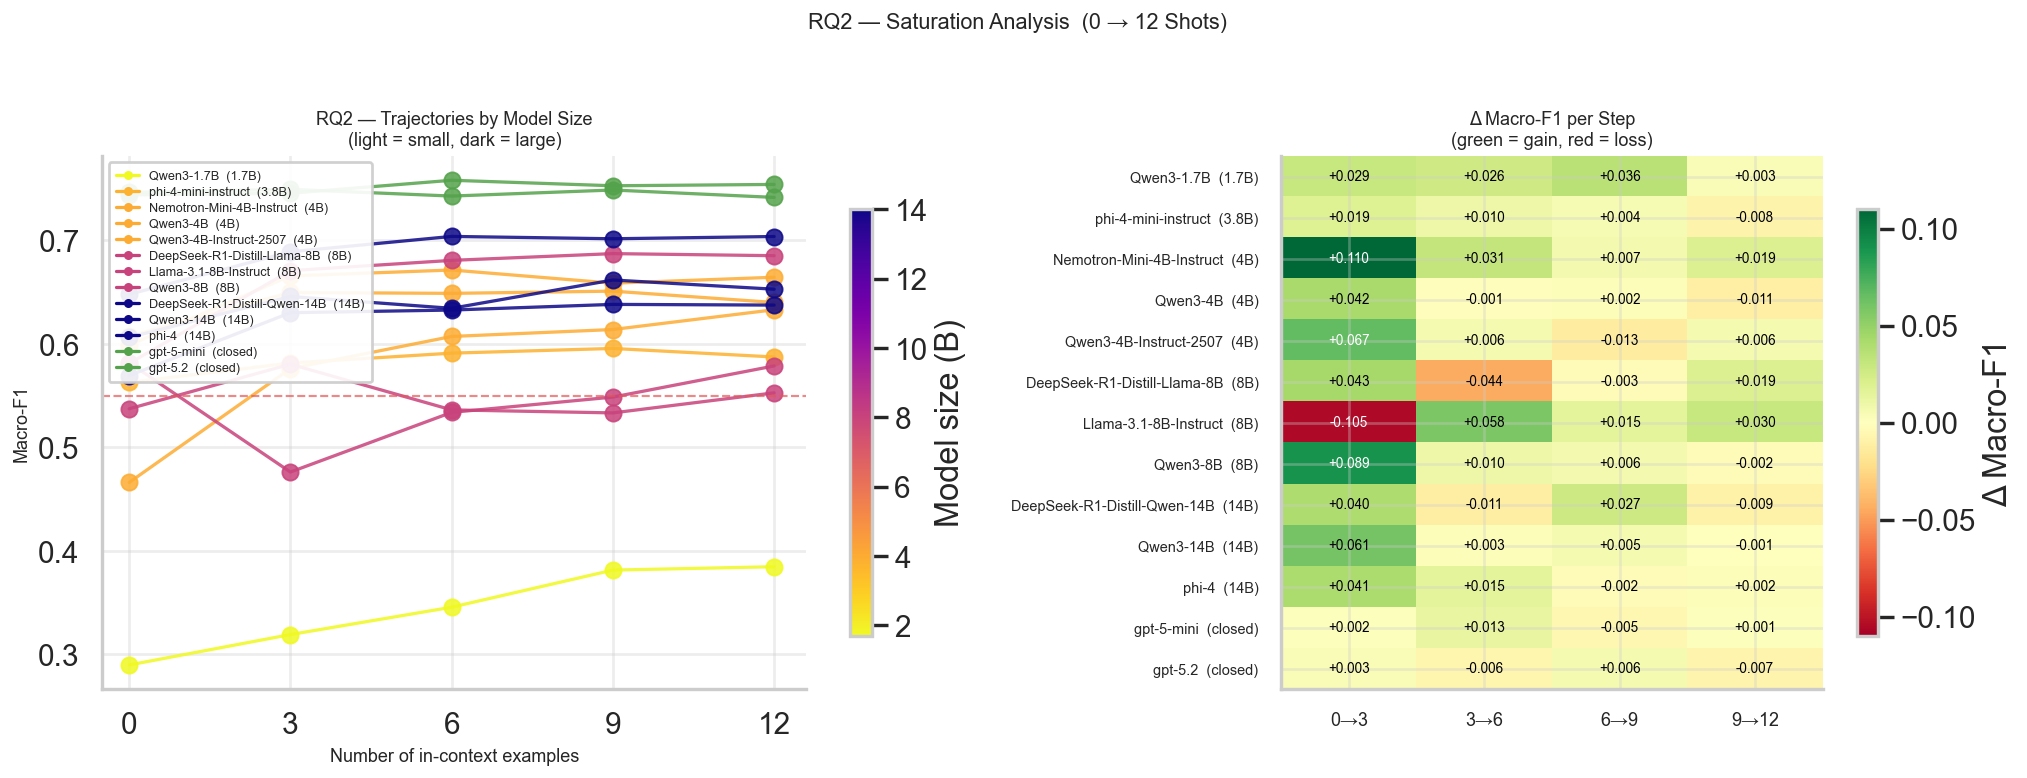

In [134]:
# ── Step-by-step delta heatmap + trajectories coloured by size ───────────
# Adapted from stance_results_team_analysis.ipynb cell 13.

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [1.3, 1]})

# Left: trajectories coloured by model size
ax = axes[0]
known_sizes = step_df['size_B'].dropna()
norm_size = mcolors.Normalize(vmin=known_sizes.min(), vmax=known_sizes.max())
cmap_size  = plt.get_cmap('plasma_r')

traj_handles = []
for _, r in step_df.iterrows():
    model = r['model']
    sub   = metrics[metrics['model'] == model].sort_values('n_shots')
    size  = r['size_B']
    color = cmap_size(norm_size(size)) if pd.notna(size) else '#54A24B'
    line, = ax.plot(sub['n_shots'], sub['macro_f1'], marker='o',
                    color=color, linewidth=1.8, alpha=0.85)
    label_str = f'{model}  ({size:g}B)' if pd.notna(size) else f'{model}  (closed)'
    traj_handles.append(Line2D([0],[0], color=color, marker='o',
                                markersize=4, linewidth=1.8, label=label_str))

ax.axhline(F1_USABLE, color='#E45756', linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xticks(ICL_SHOT_COUNTS)
ax.set_xlim(-0.5, 12.6)
ax.set_xlabel('Number of in-context examples', fontsize=10)
ax.set_ylabel('Macro-F1', fontsize=10)
ax.set_title('RQ2 \u2014 Trajectories by Model Size\n(light = small, dark = large)', fontsize=10)

sm = plt.cm.ScalarMappable(cmap=cmap_size, norm=norm_size)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Model size (B)', shrink=0.8)

# Model label legend inside the left axes (upper-left)
ax.legend(handles=traj_handles, fontsize=7, loc='upper left',
          frameon=True, framealpha=0.92, edgecolor='#cccccc',
          borderpad=0.6, labelspacing=0.3, handlelength=1.8,
          ncol=1)

# Right: step delta heatmap
ax2 = axes[1]
heat = step_df[STEP_LABELS].values.astype(float)
row_labels = [
    f'{r["model"]}  ({r["size_B"]:g}B)' if pd.notna(r['size_B'])
    else f'{r["model"]}  (closed)'
    for _, r in step_df.iterrows()
]
non_nan = heat[~np.isnan(heat)]
vlim = max(np.abs(non_nan).max(), 0.01) if len(non_nan) else 0.05
im = ax2.imshow(heat, cmap='RdYlGn', vmin=-vlim, vmax=vlim, aspect='auto')
ax2.set_xticks(range(len(STEP_LABELS)))
ax2.set_xticklabels(STEP_LABELS, fontsize=10)
ax2.set_yticks(range(len(row_labels)))
ax2.set_yticklabels(row_labels, fontsize=8)
ax2.set_title('\u0394 Macro-F1 per Step\n(green = gain, red = loss)', fontsize=10)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f'{val:+.3f}', ha='center', va='center',
                     fontsize=7.5,
                     color='black' if abs(val) < vlim * 0.6 else 'white')
plt.colorbar(im, ax=ax2, label='\u0394 Macro-F1', shrink=0.8)

plt.suptitle('RQ2 \u2014 Saturation Analysis  (0 \u2192 12 Shots)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

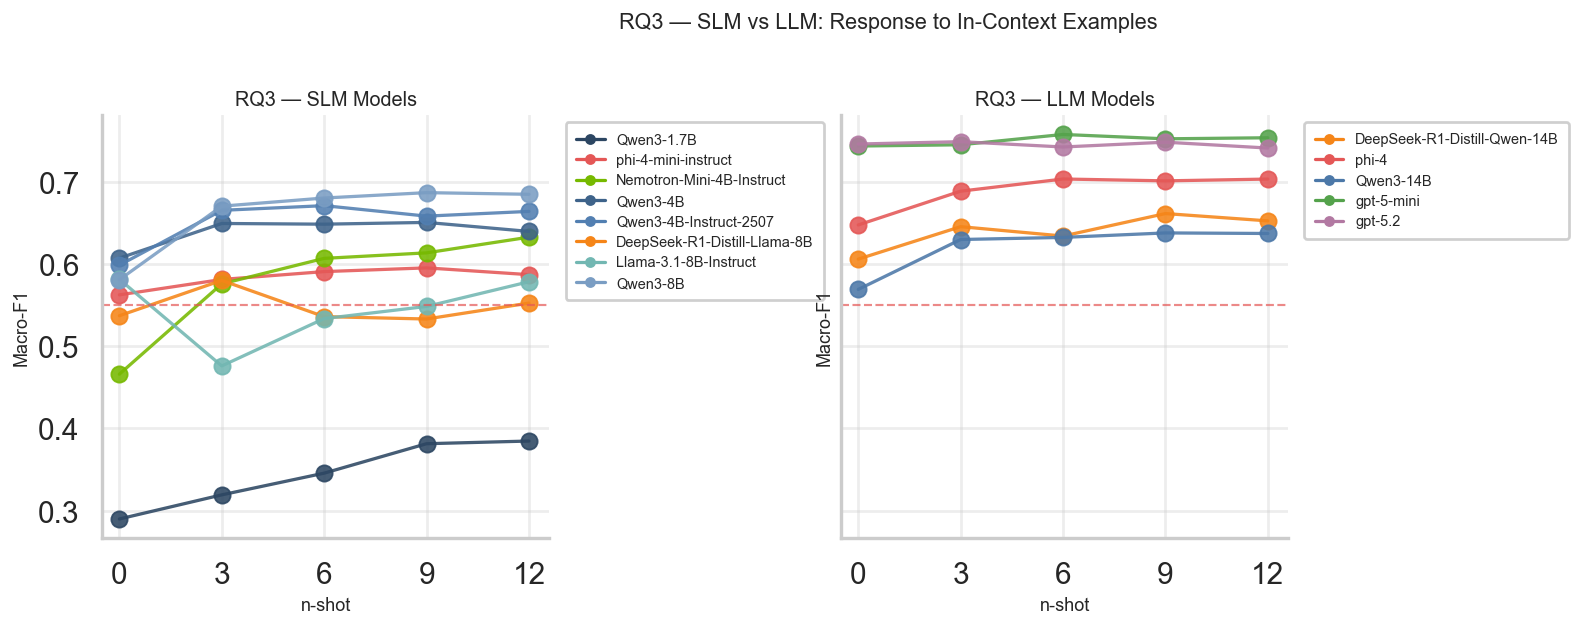

n_shots,0,3,6,9,12
tier,,,,,
LLM,0.663,0.692,0.694,0.700,0.698
SLM,0.528,0.565,0.577,0.584,0.591


In [135]:
# ── RQ3: SLM vs LLM trajectories ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, tier in zip(axes, ['SLM', 'LLM']):
    subset_models = sorted(
        metrics[metrics['tier'] == tier]['model'].unique(),
        key=model_sort_key
    )
    colors = build_model_colors(list(subset_models))
    handles = []
    for model in subset_models:
        sub   = metrics[metrics['model'] == model].sort_values('n_shots')
        color = colors.get(model, '#888888')
        ax.plot(sub['n_shots'], sub['macro_f1'], marker='o', color=color,
                linewidth=1.8, alpha=0.88)
        handles.append(Line2D([0],[0], color=color, marker='o',
                               markersize=5, linewidth=1.8, label=model))
    ax.axhline(F1_USABLE, color='#E45756', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_xticks(ICL_SHOT_COUNTS)
    ax.set_xlim(-0.5, 12.6)
    ax.set_xlabel('n-shot', fontsize=10)
    ax.set_ylabel('Macro-F1', fontsize=10)
    ax.set_title(f'RQ3 \u2014 {tier} Models', fontsize=11)
    ax.legend(handles=handles, fontsize=8,
              bbox_to_anchor=(1.02, 1), loc='upper left',
              frameon=True, framealpha=0.94, edgecolor='#cccccc',
              borderpad=0.7, labelspacing=0.45, handlelength=2.0)

plt.suptitle('RQ3 \u2014 SLM vs LLM: Response to In-Context Examples', fontsize=12)
plt.tight_layout()
plt.subplots_adjust(right=0.72)
plt.show()

# ── Group-level mean trajectory ────────────────────────────────────────────
tier_mean = (
    metrics.groupby(['tier', 'n_shots'])['macro_f1']
    .agg(['mean', 'std'])
    .reset_index()
)
display(tier_mean.pivot_table(index='tier', columns='n_shots',
                               values='mean').round(3))

---
## 4 · Per-Class Analysis

**RQ4:** Which stance classes (FAVOR / AGAINST / NONE) benefit most from additional in-context examples?

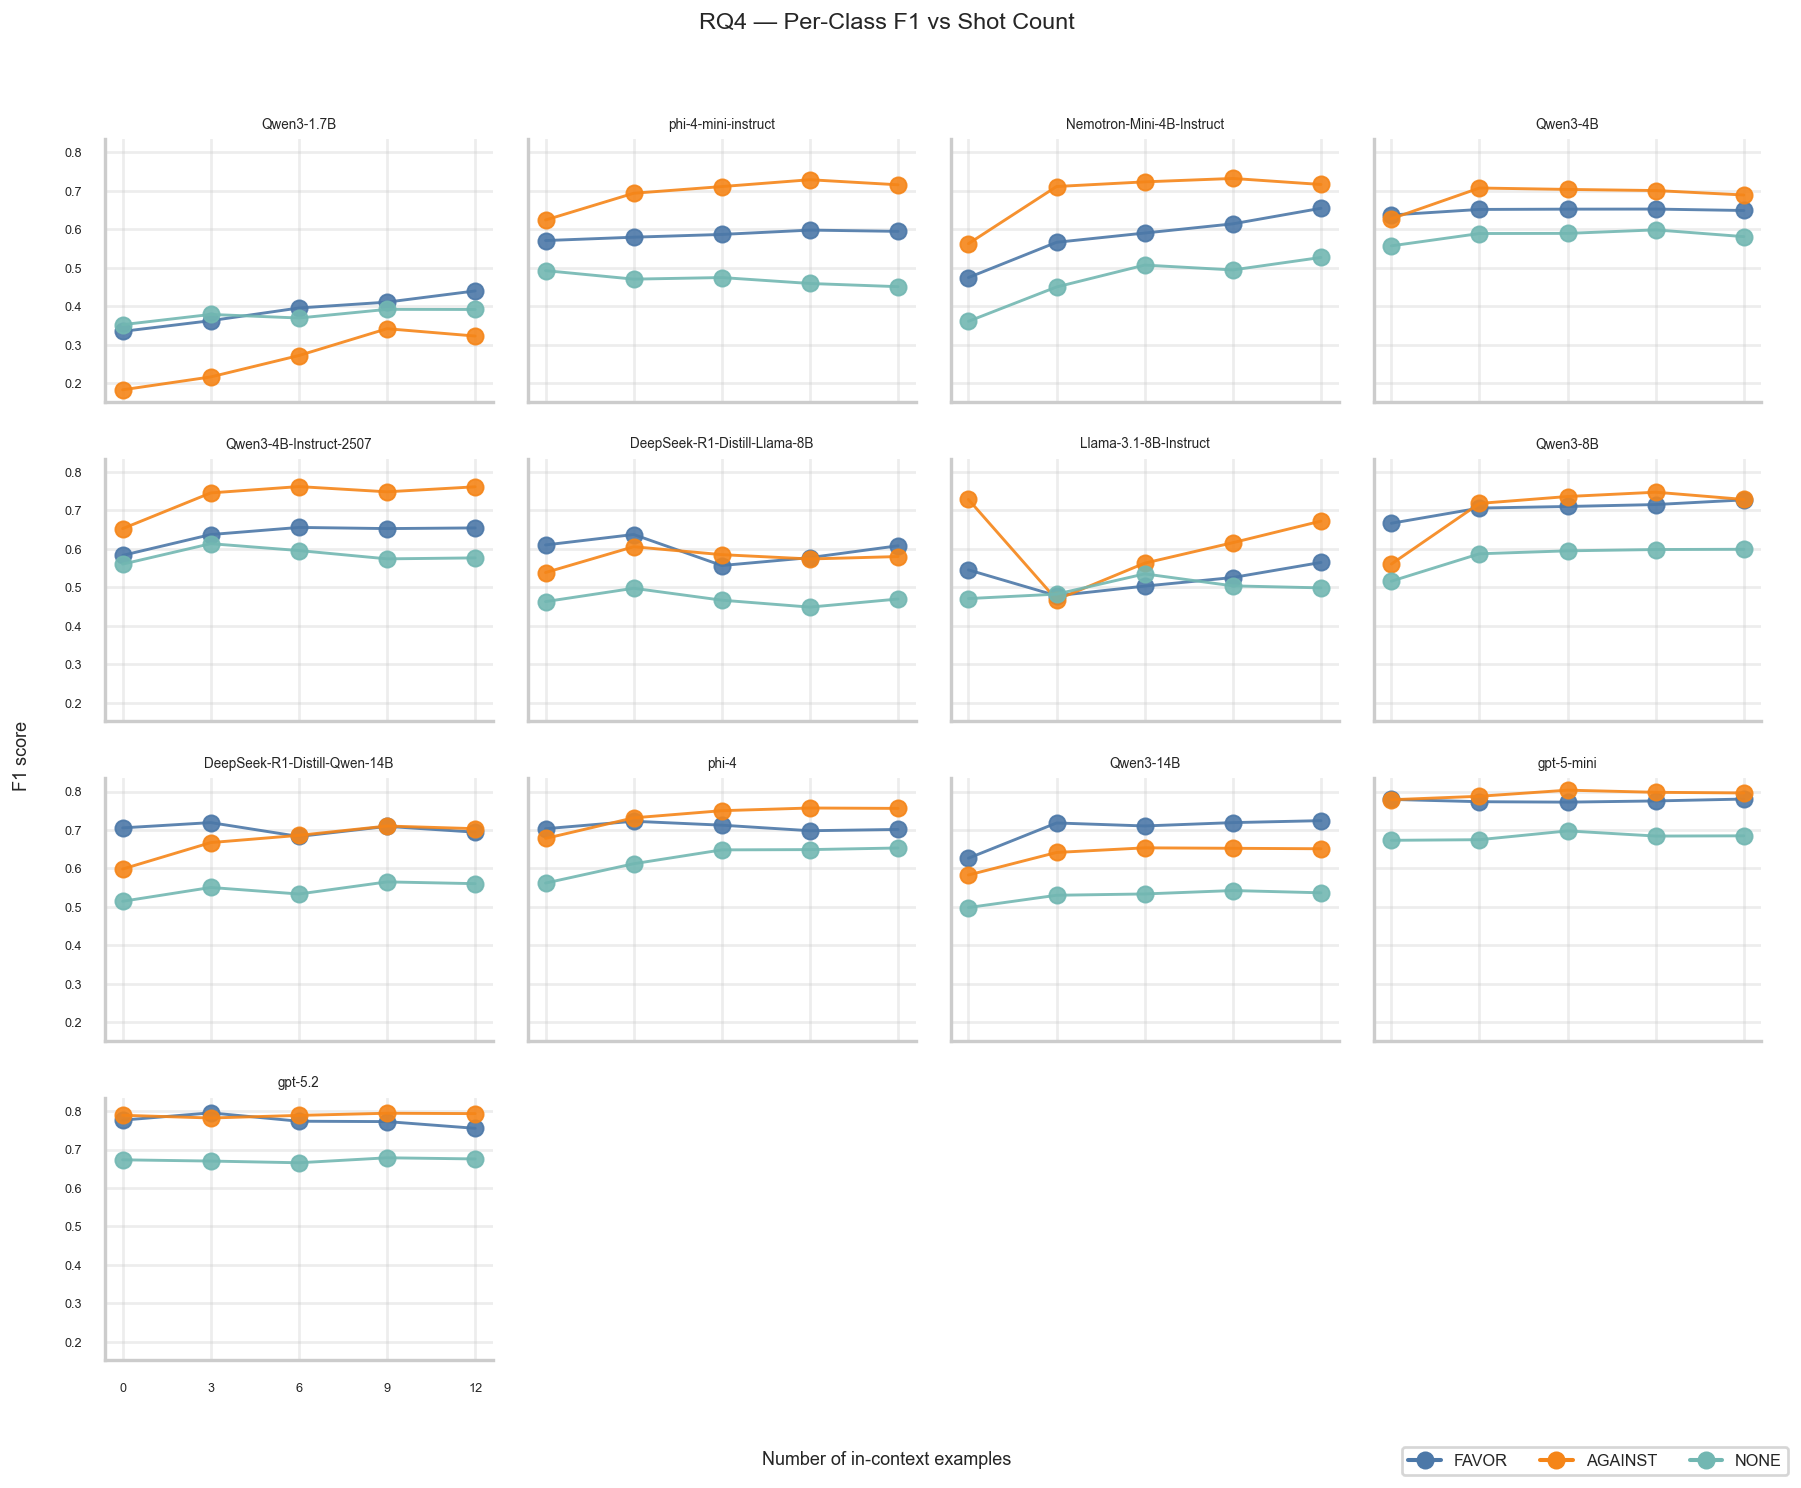

In [136]:
# ── Per-class F1 vs shot count — small multiples per model ───────────────
CLASS_COLORS = {'FAVOR': '#4C78A8', 'AGAINST': '#F58518', 'NONE': '#72B7B2'}

models_sorted = sorted(metrics['model'].unique(), key=model_sort_key)
n_models = len(models_sorted)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 3.5, nrows * 2.8),
                         sharey=True, sharex=True)
axes_flat = axes.flatten()

for idx, model in enumerate(models_sorted):
    ax  = axes_flat[idx]
    sub = metrics[metrics['model'] == model].sort_values('n_shots')
    for label in LABELS:
        ax.plot(sub['n_shots'], sub[f'f1_{label}'], marker='o',
                color=CLASS_COLORS[label], linewidth=1.6,
                alpha=0.9, label=label)
    ax.set_title(model, fontsize=7.5)
    ax.set_xticks(ICL_SHOT_COUNTS)
    ax.tick_params(labelsize=7)

for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared legend
handles = [Line2D([0],[0], color=CLASS_COLORS[l], marker='o', label=l) for l in LABELS]
fig.legend(handles=handles, loc='lower right', fontsize=9,
           ncol=3, bbox_to_anchor=(1.0, 0.0))
fig.supxlabel('Number of in-context examples', fontsize=10)
fig.supylabel('F1 score', fontsize=10)
fig.suptitle('RQ4 — Per-Class F1 vs Shot Count', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Mean F1 gain (0→12) per stance class:


,mean,std,min,max
label,,,,
AGAINST,0.076,0.063,-0.056,0.168
FAVOR,0.041,0.059,-0.021,0.180
NONE,0.039,0.051,-0.042,0.166


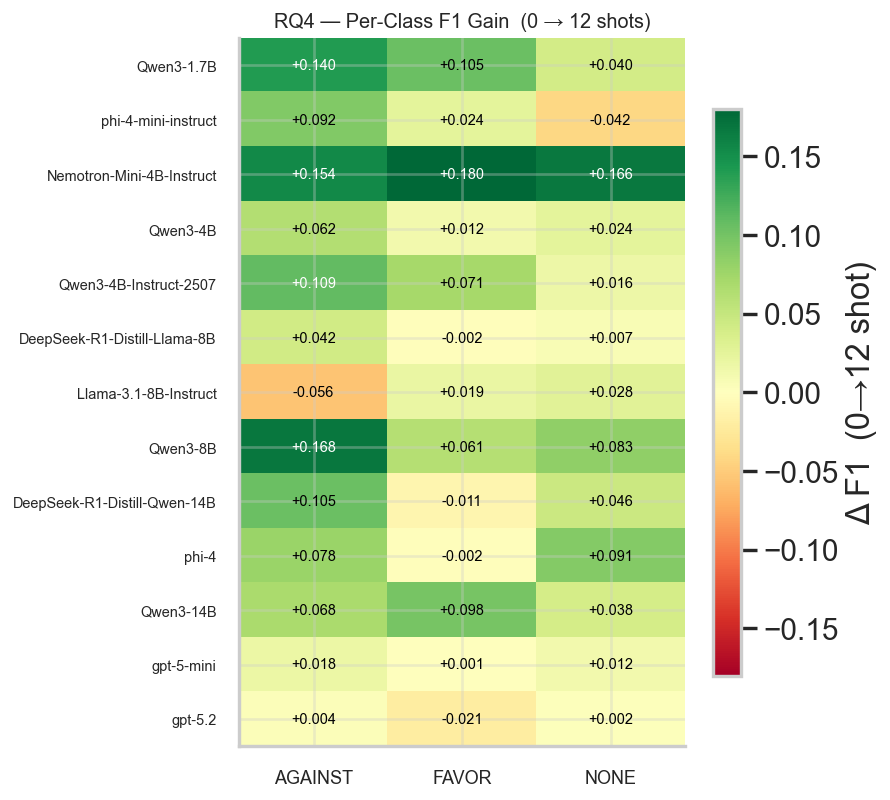

In [137]:
# ── Which class gains the most from 0 → 12 shots? ─────────────────────────
class_gain_rows = []
for model, grp in metrics.groupby('model'):
    grp = grp.set_index('n_shots')
    if 0 not in grp.index or 12 not in grp.index:
        continue
    for label in LABELS:
        col = f'f1_{label}'
        class_gain_rows.append({
            'model': model,
            'label': label,
            'f1_0shot':  grp.loc[0, col],
            'f1_12shot': grp.loc[12, col],
            'gain':      grp.loc[12, col] - grp.loc[0, col],
        })

class_gain_df = pd.DataFrame(class_gain_rows).round(3)

# Mean gain per class across models
print('Mean F1 gain (0→12) per stance class:')
display(
    class_gain_df.groupby('label')['gain']
    .agg(['mean','std','min','max'])
    .round(3)
)

# Heatmap: gain per (model, class)
heat_gain = class_gain_df.pivot(index='model', columns='label', values='gain')
heat_gain = heat_gain.reindex(index=sorted(heat_gain.index, key=model_sort_key))

fig, ax = plt.subplots(figsize=(7, max(4, len(heat_gain) * 0.5)))
vlim = max(heat_gain.abs().max().max(), 0.01)
im = ax.imshow(heat_gain.values, cmap='RdYlGn', vmin=-vlim, vmax=vlim, aspect='auto')
ax.set_xticks(range(len(heat_gain.columns)))
ax.set_xticklabels(heat_gain.columns, fontsize=10)
ax.set_yticks(range(len(heat_gain.index)))
ax.set_yticklabels(heat_gain.index, fontsize=8)
for i in range(heat_gain.shape[0]):
    for j in range(heat_gain.shape[1]):
        val = heat_gain.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                    fontsize=8, color='black' if abs(val) < vlim * 0.6 else 'white')
plt.colorbar(im, ax=ax, label='Δ F1  (0→12 shot)', shrink=0.8)
ax.set_title('RQ4 — Per-Class F1 Gain  (0 → 12 shots)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 5 · Shot-Sensitive Examples

**RQ5:** What proportion of test examples change prediction as shot count increases?

For each example × model we collect predictions at 0, 3, 6, 9, 12 shots and compute:
- **instability** = number of label flips across consecutive shot counts (0→3, 3→6, …)
- **n_unique_preds** = number of distinct labels predicted across all shot counts
- **error_rate** = fraction of shot counts where prediction ≠ gold

In [138]:
# ── Build wide example × model × shot-count prediction table ─────────────

pred_frames = []
for sys_key, df in system_frames.items():
    model  = sys_key.split(' | ')[0]
    prompt = sys_key.split(' | ')[1]
    n_shots = SHOT_MAP[prompt]
    tmp = df[['doc_id', 'gold', 'pred']].copy()
    tmp['model']   = model
    tmp['n_shots'] = n_shots
    pred_frames.append(tmp)

pred_long = pd.concat(pred_frames, ignore_index=True)

# Pivot to wide: one row per (doc_id, model), one column per shot count
pred_wide = pred_long.pivot_table(
    index=['doc_id', 'model', 'gold'],
    columns='n_shots',
    values='pred',
    aggfunc='first'
).reset_index()
pred_wide.columns.name = None
shot_cols = [c for c in ICL_SHOT_COUNTS if c in pred_wide.columns]

print(f'Rows (doc × model): {len(pred_wide)}')
print(f'Shot columns present: {shot_cols}')
pred_wide.head(3)

Rows (doc × model): 16237
Shot columns present: [0, 3, 6, 9, 12]


,doc_id,model,gold,0,3,6,9,12
0,10001,DeepSeek-R1-Distill-Llama-8B,AGAINST,NONE,NONE,NONE,NONE,NONE
1,10001,DeepSeek-R1-Distill-Qwen-14B,AGAINST,NONE,NONE,NONE,NONE,NONE
2,10001,Llama-3.1-8B-Instruct,AGAINST,AGAINST,FAVOR,FAVOR,FAVOR,FAVOR


In [139]:
# ── Compute per-row instability metrics ───────────────────────────────────

def count_flips(row, cols):
    """Number of label changes across consecutive shot counts."""
    preds = [row[c] for c in cols if not pd.isna(row[c])]
    return sum(a != b for a, b in zip(preds, preds[1:]))

def n_unique(row, cols):
    preds = [row[c] for c in cols if not pd.isna(row[c])]
    return len(set(preds))

def error_rate(row, cols):
    preds = [row[c] for c in cols if not pd.isna(row[c])]
    if not preds:
        return np.nan
    return sum(p != row['gold'] for p in preds) / len(preds)

pred_wide['instability']   = pred_wide.apply(count_flips,  cols=shot_cols, axis=1)
pred_wide['n_unique_preds']= pred_wide.apply(n_unique,     cols=shot_cols, axis=1)
pred_wide['error_rate']    = pred_wide.apply(error_rate,   cols=shot_cols, axis=1)
pred_wide['any_change']    = pred_wide['instability'] > 0
pred_wide['multi_change']  = pred_wide['instability'] > 1
pred_wide['always_stable'] = pred_wide['instability'] == 0

pred_wide.head(3)

,doc_id,model,gold,0,3,6,9,12,instability,n_unique_preds,error_rate,any_change,multi_change,always_stable
0,10001,DeepSeek-R1-Distill-Llama-8B,AGAINST,NONE,NONE,NONE,NONE,NONE,0,1,1.000,False,False,True
1,10001,DeepSeek-R1-Distill-Qwen-14B,AGAINST,NONE,NONE,NONE,NONE,NONE,0,1,1.000,False,False,True
2,10001,Llama-3.1-8B-Instruct,AGAINST,AGAINST,FAVOR,FAVOR,FAVOR,FAVOR,1,2,0.800,True,False,False


In [140]:
# ── Per-model summary ─────────────────────────────────────────────────────
stability_summary = (
    pred_wide.groupby('model')
    .agg(
        pct_any_change   = ('any_change',    'mean'),
        pct_multi_change = ('multi_change',  'mean'),
        pct_stable       = ('always_stable', 'mean'),
        mean_instability = ('instability',   'mean'),
        mean_error_rate  = ('error_rate',    'mean'),
    )
    .reset_index()
    .sort_values('mean_instability', ascending=False)
)
stability_summary[['pct_any_change','pct_multi_change','pct_stable']] *= 100
stability_summary = stability_summary.round(2)
display(stability_summary)

,model,pct_any_change,pct_multi_change,pct_stable,mean_instability,mean_error_rate
0,DeepSeek-R1-Distill-Llama-8B,47.800,33.470,52.200,0.960,0.460
2,Llama-3.1-8B-Instruct,53.640,22.820,46.360,0.810,0.440
6,Qwen3-4B,38.670,24.260,61.330,0.730,0.350
3,Nemotron-Mini-4B-Instruct,46.520,18.410,53.480,0.690,0.390
8,Qwen3-8B,38.910,20.900,61.090,0.680,0.330
1,DeepSeek-R1-Distill-Qwen-14B,33.150,19.940,66.850,0.620,0.360
12,phi-4-mini-instruct,39.230,16.170,60.770,0.590,0.380
5,Qwen3-14B,27.780,17.930,72.220,0.520,0.380
4,Qwen3-1.7B,30.660,12.170,69.340,0.470,0.660
7,Qwen3-4B-Instruct-2507,30.740,10.730,69.260,0.440,0.320


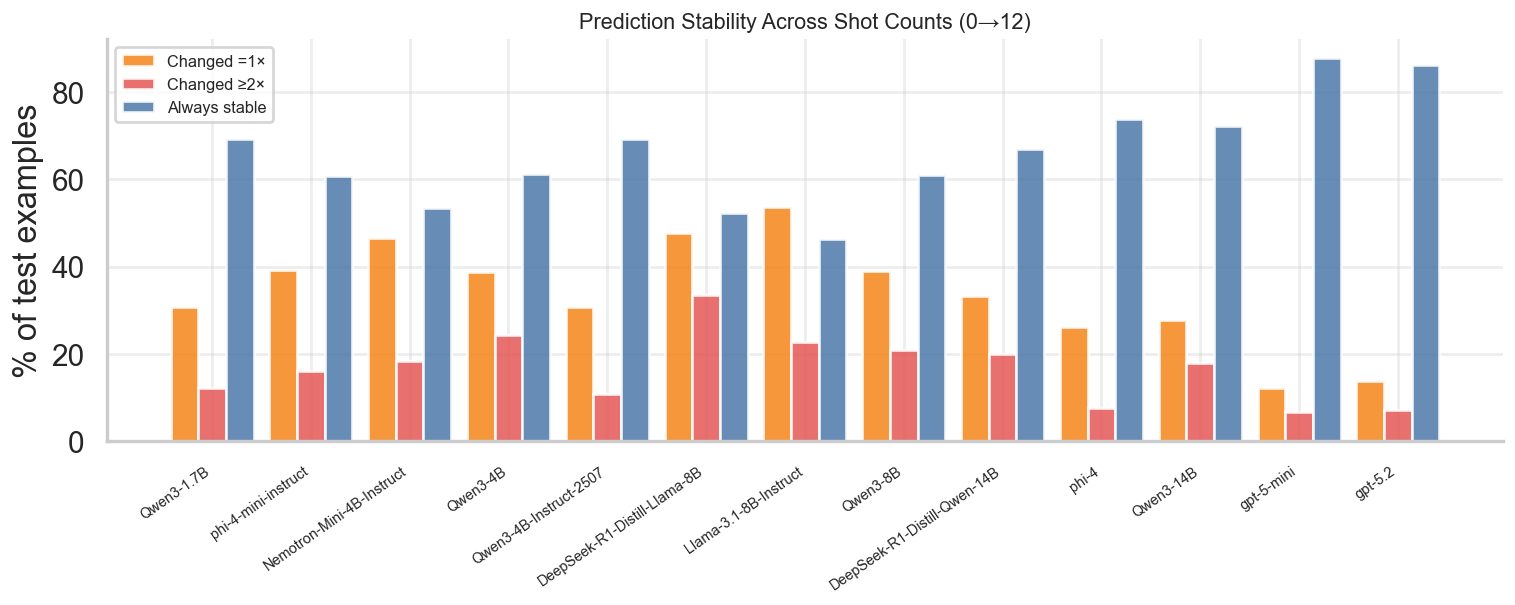

In [162]:
# ── Bar chart: % examples that change prediction ──────────────────────────
stab = stability_summary.sort_values('model', key=lambda s: s.map(model_sort_key))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(stab))
w = 0.28
ax.bar(x - w,   stab['pct_any_change'],   width=w, label='Changed =1×', color='#F58518', alpha=0.85)
ax.bar(x,       stab['pct_multi_change'], width=w, label='Changed ≥2×', color='#E45756', alpha=0.85)
ax.bar(x + w,   stab['pct_stable'],       width=w, label='Always stable', color='#4C78A8', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(stab['model'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('% of test examples')
ax.set_title('Prediction Stability Across Shot Counts (0→12)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 6 · Helped vs Harmed Examples

**RQ6:** Which examples are corrected by more shots, and which are harmed?

We classify each (example, model) pair into five categories:  
- **stable_correct** — always predicted correctly  
- **stable_wrong** — always predicted incorrectly  
- **corrected** — wrong at 0-shot, correct at 12-shot  
- **harmed** — correct at 0-shot, wrong at 12-shot  
- **unstable** — prediction flips more than once  

*Note: 0-shot = `task_definition`; 12-shot = `few_shot_12`.*

In [142]:
# ── Classify each (doc, model) pair ──────────────────────────────────────

def classify_trajectory(row, shot_cols, gold_col='gold'):
    gold       = row[gold_col]
    pred_0     = row.get(0)   if 0  in shot_cols else np.nan
    pred_12    = row.get(12)  if 12 in shot_cols else np.nan
    flips      = row['instability']

    if pd.isna(pred_0) or pd.isna(pred_12):
        return 'incomplete'
    correct_0  = pred_0  == gold
    correct_12 = pred_12 == gold

    if flips > 1:
        return 'unstable'
    if correct_0 and correct_12:
        return 'stable_correct'
    if not correct_0 and not correct_12:
        return 'stable_wrong'
    if not correct_0 and correct_12:
        return 'corrected'
    if correct_0 and not correct_12:
        return 'harmed'
    return 'other'

pred_wide['trajectory'] = pred_wide.apply(
    classify_trajectory, shot_cols=shot_cols, axis=1
)

traj_summary = (
    pred_wide.groupby(['model', 'trajectory'])
    .size()
    .reset_index(name='count')
    .pivot_table(index='model', columns='trajectory', values='count', fill_value=0)
)
traj_pct = traj_summary.div(traj_summary.sum(axis=1), axis=0) * 100
traj_pct = traj_pct.reindex(
    sorted(traj_pct.index, key=model_sort_key)
).round(1)

print('Trajectory breakdown (% of test examples per model):')
display(traj_pct)

Trajectory breakdown (% of test examples per model):


trajectory,corrected,harmed,incomplete,stable_correct,stable_wrong,unstable
model,,,,,,
Qwen3-1.7B,10.600,2.700,0.000,23.800,50.800,12.200
phi-4-mini-instruct,12.800,7.400,0.000,43.700,19.900,16.200
Nemotron-Mini-4B-Instruct,19.800,5.300,0.000,37.600,18.900,18.400
Qwen3-4B,7.600,4.700,1.000,46.300,16.400,23.900
Qwen3-4B-Instruct-2507,12.700,5.400,0.000,52.700,18.600,10.700
DeepSeek-R1-Distill-Llama-8B,6.700,5.600,0.200,32.700,21.400,33.400
Llama-3.1-8B-Instruct,10.200,13.100,0.000,34.900,19.000,22.800
Qwen3-8B,13.100,2.900,0.800,46.800,15.800,20.700
DeepSeek-R1-Distill-Qwen-14B,8.300,3.000,0.000,48.700,20.000,19.900


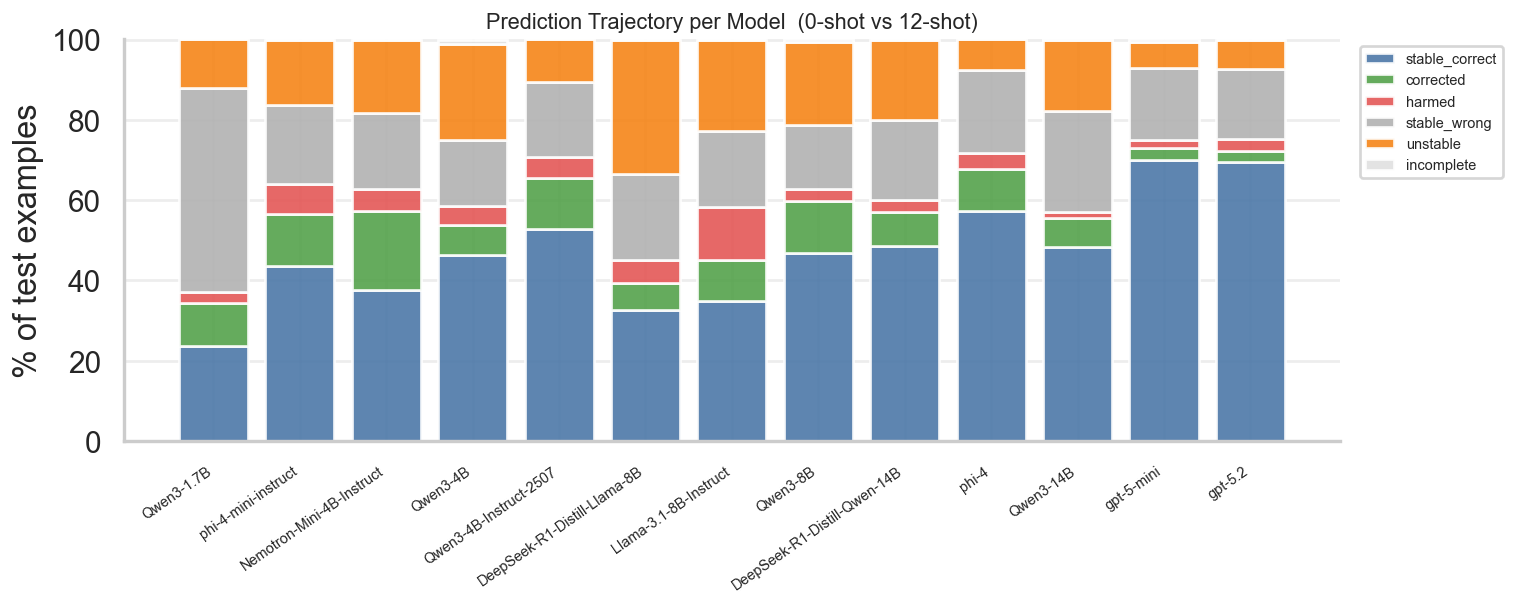

In [161]:
# ── Stacked bar: trajectory breakdown per model ───────────────────────────
TRAJ_COLORS = {
    'stable_correct': '#4C78A8',
    'corrected':      '#54A24B',
    'harmed':         '#E45756',
    'stable_wrong':   '#B2B2B2',
    'unstable':       '#F58518',
    'incomplete':     '#E0E0E0',
}
plot_cols = [c for c in TRAJ_COLORS if c in traj_pct.columns]

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(traj_pct))
for col in plot_cols:
    vals = traj_pct[col].values if col in traj_pct.columns else np.zeros(len(traj_pct))
    ax.bar(traj_pct.index, vals, bottom=bottom,
           color=TRAJ_COLORS[col], label=col, alpha=0.9)
    bottom += vals

ax.set_xticklabels(traj_pct.index, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('% of test examples')
ax.set_title('Prediction Trajectory per Model  (0-shot vs 12-shot)', fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [144]:
# ── Corrected vs harmed — which gold classes are involved? ────────────────
for traj in ['corrected', 'harmed']:
    sub = pred_wide[pred_wide['trajectory'] == traj]
    if len(sub) == 0:
        print(f'No examples classified as "{traj}".')
        continue
    print(f'\n--- {traj.upper()} examples: gold label distribution ---')
    print(sub.groupby(['model', 'gold']).size()
             .unstack(fill_value=0)
             .reindex(sorted(sub['model'].unique(), key=model_sort_key))
             .to_string())


--- CORRECTED examples: gold label distribution ---
gold                          AGAINST  FAVOR  NONE
model                                             
Qwen3-1.7B                         73     47    12
phi-4-mini-instruct               120     37     3
Nemotron-Mini-4B-Instruct         157     39    51
Qwen3-4B                           65     20    10
Qwen3-4B-Instruct-2507            120     31     7
DeepSeek-R1-Distill-Llama-8B       49     18    17
Llama-3.1-8B-Instruct              13    103    11
Qwen3-8B                          129     32     2
DeepSeek-R1-Distill-Qwen-14B       87     11     6
phi-4                              95     37     0
Qwen3-14B                          57     31     1
gpt-5-mini                         27      9     4
gpt-5.2                            21      6     9

--- HARMED examples: gold label distribution ---
gold                          AGAINST  FAVOR  NONE
model                                             
Qwen3-1.7B                    

---
## 7 · Cross-Model Example Analysis

**RQ7 / RQ8:** Which examples remain unstable across shot counts *and* across models?  
Are there examples that are difficult mainly for SLMs but not for LLMs?

We build an example-level table aggregating signals across all models.

In [145]:
# ── Aggregate per-example across models ──────────────────────────────────
n_models_total = pred_wide['model'].nunique()

example_agg = (
    pred_wide.groupby('doc_id')
    .agg(
        gold            = ('gold',          'first'),
        n_models_any_change = ('any_change',    'sum'),
        n_models_wrong_12   = (12,              lambda x: (x != pred_wide.loc[x.index, 'gold']).sum()),
        n_models_corrected  = ('trajectory',    lambda x: (x == 'corrected').sum()),
        n_models_harmed     = ('trajectory',    lambda x: (x == 'harmed').sum()),
        n_models_unstable   = ('trajectory',    lambda x: (x == 'unstable').sum()),
        mean_error_rate     = ('error_rate',    'mean'),
        mean_instability    = ('instability',   'mean'),
    )
    .reset_index()
)

# SLM-specific vs LLM-specific difficulty
slm_models = [m for m in pred_wide['model'].unique() if is_slm(m)]
llm_models = [m for m in pred_wide['model'].unique() if is_llm(m)]

for tier_name, tier_models in [('slm', slm_models), ('llm', llm_models)]:
    tier_sub = pred_wide[pred_wide['model'].isin(tier_models)]
    tier_agg = (
        tier_sub.groupby('doc_id')
        .agg(**{f'mean_err_{tier_name}': ('error_rate', 'mean')})
        .reset_index()
    )
    example_agg = example_agg.merge(tier_agg, on='doc_id', how='left')

# Hard mainly for SLMs: high SLM error rate AND low LLM error rate
if 'mean_err_slm' in example_agg.columns and 'mean_err_llm' in example_agg.columns:
    example_agg['slm_only_hard'] = (
        (example_agg['mean_err_slm'] > 0.5) &
        (example_agg['mean_err_llm'] < 0.3)
    )
    example_agg['llm_only_hard'] = (
        (example_agg['mean_err_llm'] > 0.5) &
        (example_agg['mean_err_slm'] < 0.3)
    )

example_agg = example_agg.round(3)
print(f'Total unique examples: {len(example_agg)}')
example_agg.sort_values('mean_instability', ascending=False).head(10)

Total unique examples: 1249


,doc_id,gold,n_models_any_change,n_models_wrong_12,n_models_corrected,n_models_harmed,n_models_unstable,mean_error_rate,mean_instability,mean_err_slm,mean_err_llm,slm_only_hard,llm_only_hard
445,10446,AGAINST,11,10,2,0,8,0.646,1.923,0.725,0.520,False,False
668,10669,FAVOR,10,9,0,2,8,0.631,1.769,0.625,0.640,False,False
205,10206,FAVOR,9,8,0,0,9,0.538,1.769,0.650,0.360,False,False
543,10544,AGAINST,10,8,2,0,8,0.615,1.769,0.525,0.760,False,False
66,10067,AGAINST,8,6,0,0,8,0.477,1.769,0.600,0.280,True,False
108,10109,AGAINST,11,6,4,0,7,0.569,1.692,0.675,0.400,False,False
593,10594,AGAINST,9,4,1,2,6,0.385,1.692,0.375,0.400,False,False
490,10491,AGAINST,10,7,0,1,8,0.477,1.615,0.350,0.680,False,False
723,10724,NONE,11,8,0,3,6,0.523,1.615,0.525,0.520,False,False
447,10448,AGAINST,8,10,0,0,7,0.888,1.615,0.850,0.950,False,False


In [146]:
# ── Top-N most shot-sensitive examples (ranked by mean instability) ───────
TOP_N = 20

top_unstable = example_agg.nlargest(TOP_N, 'mean_instability')
print(f'Top {TOP_N} most shot-sensitive examples (highest mean instability across models):')
display(top_unstable[['doc_id', 'gold', 'n_models_any_change',
                       'n_models_wrong_12', 'n_models_corrected',
                       'n_models_harmed', 'n_models_unstable',
                       'mean_error_rate', 'mean_instability']])

Top 20 most shot-sensitive examples (highest mean instability across models):


,doc_id,gold,n_models_any_change,n_models_wrong_12,n_models_corrected,n_models_harmed,n_models_unstable,mean_error_rate,mean_instability
445,10446,AGAINST,11,10,2,0,8,0.646,1.923
66,10067,AGAINST,8,6,0,0,8,0.477,1.769
205,10206,FAVOR,9,8,0,0,9,0.538,1.769
543,10544,AGAINST,10,8,2,0,8,0.615,1.769
668,10669,FAVOR,10,9,0,2,8,0.631,1.769
108,10109,AGAINST,11,6,4,0,7,0.569,1.692
593,10594,AGAINST,9,4,1,2,6,0.385,1.692
352,10353,NONE,12,8,0,4,7,0.538,1.615
447,10448,AGAINST,8,10,0,0,7,0.888,1.615
490,10491,AGAINST,10,7,0,1,8,0.477,1.615


In [147]:
# ── RQ8: Examples hard mainly for SLMs ───────────────────────────────────
if 'slm_only_hard' in example_agg.columns:
    slm_hard = example_agg[example_agg['slm_only_hard']]
    print(f'Examples hard for SLMs but not LLMs: {len(slm_hard)}')
    display(slm_hard[['doc_id', 'gold', 'mean_err_slm', 'mean_err_llm',
                       'mean_instability']].head(20))
else:
    print('SLM/LLM split unavailable — check that both tier groups have results.')

# Distribution of gold labels among SLM-hard examples
if 'slm_only_hard' in example_agg.columns and len(slm_hard) > 0:
    print('\nGold label distribution in SLM-hard examples:')
    print(slm_hard['gold'].value_counts().to_string())

Examples hard for SLMs but not LLMs: 104


,doc_id,gold,mean_err_slm,mean_err_llm,mean_instability
25,10026,AGAINST,0.700,0.160,1.077
37,10038,AGAINST,0.850,0.240,1.231
39,10040,AGAINST,0.525,0.120,1.154
47,10048,AGAINST,0.550,0.120,1.077
57,10058,AGAINST,0.600,0.080,0.769
58,10059,AGAINST,0.650,0.280,1.231
60,10061,AGAINST,0.525,0.200,1.077
66,10067,AGAINST,0.600,0.280,1.769
71,10072,FAVOR,0.650,0.040,0.769
99,10100,AGAINST,0.625,0.120,1.000



Gold label distribution in SLM-hard examples:
gold
AGAINST    45
FAVOR      36
NONE       23


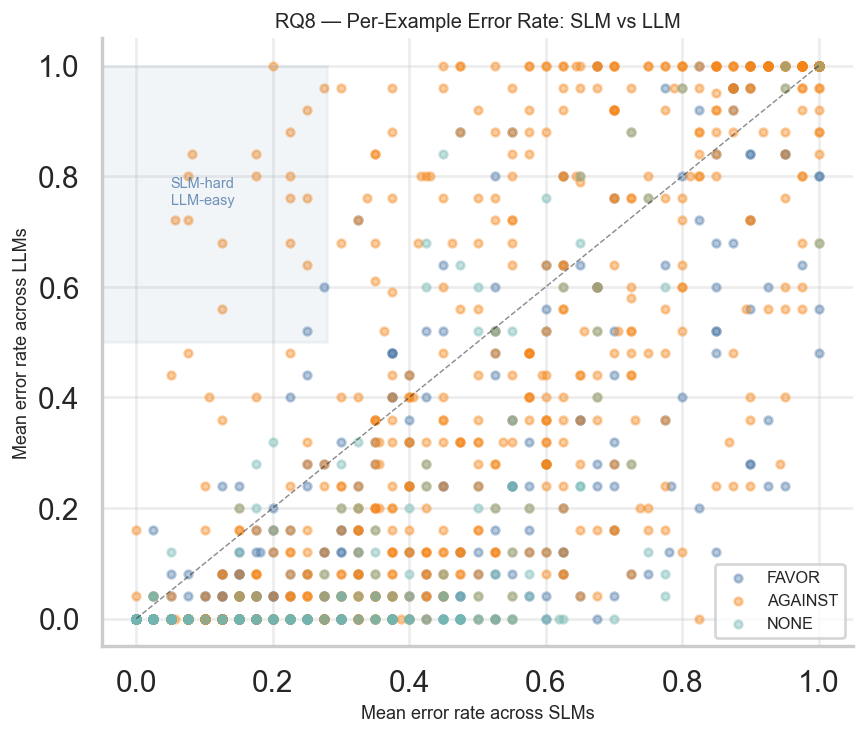

In [148]:
# ── Scatter: SLM error rate vs LLM error rate (per example) ──────────────
if 'mean_err_slm' in example_agg.columns and 'mean_err_llm' in example_agg.columns:
    label_colors = {'FAVOR': '#4C78A8', 'AGAINST': '#F58518', 'NONE': '#72B7B2'}
    plot_df = example_agg.dropna(subset=['mean_err_slm', 'mean_err_llm'])

    fig, ax = plt.subplots(figsize=(7, 6))
    for label in LABELS:
        sub = plot_df[plot_df['gold'] == label]
        ax.scatter(sub['mean_err_slm'], sub['mean_err_llm'],
                   color=label_colors[label], alpha=0.4, s=18, label=label)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.axhspan(0.5, 1.0, xmin=0.0, xmax=0.3, color='#4C78A8', alpha=0.07)
    ax.text(0.05, 0.75, 'SLM-hard\nLLM-easy', fontsize=8, color='#4C78A8', alpha=0.8)
    ax.set_xlabel('Mean error rate across SLMs', fontsize=10)
    ax.set_ylabel('Mean error rate across LLMs', fontsize=10)
    ax.set_title('RQ8 — Per-Example Error Rate: SLM vs LLM', fontsize=11)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 8 · Qualitative Inspection

This section prints the most interesting examples in a human-readable format so that a researcher can manually inspect them.

The data contains `content` (tweet text) and `query` (target topic) columns which we use here.

> **Note:** If `content` is missing from the loaded data (e.g., because the pipeline was run without storing the raw text), you will see `[content not available]`. In that case, you can join on `doc_id` against the original gold dataset at `data_in/semeval2016_task6_testdata_gold`.

In [149]:
# ── Build a lookup: doc_id → (content, query) ─────────────────────────────
# We grab these fields from any available result frame that contains them.

doc_meta = {}  # doc_id -> {'content': ..., 'query': ...}
for sys_key, df in system_frames.items():
    for _, row in df.iterrows():
        did = str(row['doc_id'])
        if did not in doc_meta:
            doc_meta[did] = {
                'content': row.get('content', '[content not available]'),
                'query':   row.get('query',   '[query not available]'),
            }

print(f'doc_meta entries: {len(doc_meta)}')
# sample
sample_id = list(doc_meta.keys())[0]
print(f'\nSample doc_id={sample_id}:', doc_meta[sample_id])

doc_meta entries: 1249

Sample doc_id=10001: {'content': 'He who exalts himself shall be humbled; and he who humbles himself shall be exalted.Matt 23:12.     #SemST', 'query': 'Atheism'}


In [150]:
# ── Helper to display predictions across shots for a list of doc_ids ──────

def inspect_examples(doc_ids, title='Examples', models=None, max_models=6):
    """Print text, target, gold label, and per-model shot predictions."""
    if models is None:
        models = sorted(pred_wide['model'].unique(), key=model_sort_key)[:max_models]

    print(f'{'='*80}')
    print(f'  {title}')
    print(f'{'='*80}')
    for doc_id in doc_ids:
        meta  = doc_meta.get(str(doc_id), {})
        rows  = pred_wide[pred_wide['doc_id'].astype(str) == str(doc_id)]
        gold  = rows['gold'].values[0] if len(rows) else '?'

        print(f'\ndoc_id : {doc_id}')
        print(f'target : {meta.get("query", "[n/a]")}')
        print(f'gold   : {gold}')
        print(f'text   : {str(meta.get("content", "[n/a]"))[:140]}')
        print(f'{"-"*60}')
        print(f'  {"Model":<42}', end='')
        for s in shot_cols:
            print(f'{s:>8}-shot', end='')
        print()
        for model in models:
            row = rows[rows['model'] == model]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            print(f'  {model:<42}', end='')
            for s in shot_cols:
                pred = row.get(s, '—')
                marker = '✓' if pred == gold else '✗'
                print(f'{str(pred)+marker:>12}', end='')
            print()

In [151]:
# ── 8a: Most shot-sensitive examples (highest mean instability) ───────────
top_ids = example_agg.nlargest(10, 'mean_instability')['doc_id'].tolist()
inspect_examples(top_ids, title='Top-10 Most Shot-Sensitive Examples (all models)')

  Top-10 Most Shot-Sensitive Examples (all models)

doc_id : 10446
target : Feminist Movement
gold   : AGAINST
text   : It wouldn't be a #FIFA event without women in tight dresses. Wrong place. Wrong time. #womensworldcup #SemST
------------------------------------------------------------
  Model                                            0-shot       3-shot       6-shot       9-shot      12-shot
  Qwen3-1.7B                                       NONE✗       NONE✗       NONE✗       NONE✗       NONE✗
  phi-4-mini-instruct                             FAVOR✗       NONE✗       NONE✗      FAVOR✗       NONE✗
  Nemotron-Mini-4B-Instruct                     AGAINST✓      FAVOR✗    AGAINST✓    AGAINST✓       NONE✗
  Qwen3-4B                                        FAVOR✗       NONE✗      FAVOR✗       NONE✗      FAVOR✗
  Qwen3-4B-Instruct-2507                          FAVOR✗      FAVOR✗      FAVOR✗       NONE✗       NONE✗
  DeepSeek-R1-Distill-Llama-8B                     NONE✗      FAVOR✗       

In [152]:
# ── 8b: Examples corrected by more shots (most corrected across models) ───
corrected_ids = (
    example_agg.nlargest(8, 'n_models_corrected')['doc_id'].tolist()
)
inspect_examples(corrected_ids, title='Top-8 Examples Most Corrected by More Shots')

  Top-8 Examples Most Corrected by More Shots

doc_id : 10327
target : Climate Change is a Real Concern
gold   : FAVOR
text   : RT @TheCLF: Thanks to everyone in Maine who contacted their legislators in support of #energyefficiency funding! #MEpoli #SemST
------------------------------------------------------------
  Model                                            0-shot       3-shot       6-shot       9-shot      12-shot
  Qwen3-1.7B                                       NONE✗       NONE✗       NONE✗       NONE✗       NONE✗
  phi-4-mini-instruct                              NONE✗      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓
  Nemotron-Mini-4B-Instruct                        NONE✗      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓
  Qwen3-4B                                         NONE✗      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓
  Qwen3-4B-Instruct-2507                           NONE✗       NONE✗      FAVOR✓      FAVOR✓       NONE✗
  DeepSeek-R1-Distill-Llama-8B                  

In [153]:
# ── 8c: Examples harmed by more shots (most harmed across models) ─────────
harmed_ids = (
    example_agg.nlargest(8, 'n_models_harmed')['doc_id'].tolist()
)
inspect_examples(harmed_ids, title='Top-8 Examples Most Harmed by More Shots')

  Top-8 Examples Most Harmed by More Shots

doc_id : 10259
target : Climate Change is a Real Concern
gold   : NONE
text   : It's most exciting to witness a major development! @urgenda #SemST
------------------------------------------------------------
  Model                                            0-shot       3-shot       6-shot       9-shot      12-shot
  Qwen3-1.7B                                       NONE✓       NONE✓      FAVOR✗      FAVOR✗      FAVOR✗
  phi-4-mini-instruct                              NONE✓      FAVOR✗      FAVOR✗      FAVOR✗      FAVOR✗
  Nemotron-Mini-4B-Instruct                        NONE✓       NONE✓       NONE✓       NONE✓      FAVOR✗
  Qwen3-4B                                         NONE✓      FAVOR✗      FAVOR✗      FAVOR✗      FAVOR✗
  Qwen3-4B-Instruct-2507                           NONE✓      FAVOR✗      FAVOR✗      FAVOR✗      FAVOR✗
  DeepSeek-R1-Distill-Llama-8B                     NONE✓       NONE✓      FAVOR✗       NONE✓      FAVOR✗

doc_id 

In [154]:
# ── 8d: Examples hard for SLMs but not LLMs ──────────────────────────────
if 'slm_only_hard' in example_agg.columns:
    slm_hard_ids = (
        example_agg[example_agg['slm_only_hard']]
        .nlargest(8, 'mean_err_slm')['doc_id'].tolist()
    )
    inspect_examples(slm_hard_ids,
                     title='Top-8 Examples Hard for SLMs but Easy for LLMs')
else:
    print('SLM-specific difficulty analysis not available.')

  Top-8 Examples Hard for SLMs but Easy for LLMs

doc_id : 11123
target : Legalization of Abortion
gold   : FAVOR
text   : Yea, let's make a woman suffer 18 years and raise a child with an unfit parent who hates it because of "morality". #SemST
------------------------------------------------------------
  Model                                            0-shot       3-shot       6-shot       9-shot      12-shot
  Qwen3-1.7B                                      FAVOR✓    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗
  phi-4-mini-instruct                           AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗
  Nemotron-Mini-4B-Instruct                     AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗
  Qwen3-4B                                      AGAINST✗    AGAINST✗      FAVOR✓    AGAINST✗    AGAINST✗
  Qwen3-4B-Instruct-2507                        AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗
  DeepSeek-R1-Distill-Llama-8B                  AGAINST✗   

---
## Summary of Key Findings

| # | Research question | Key result |
|---|-------------------|------------|
| 1 | **Performance vs shot count** | Performance improves for 11/13 models from 0→12 shots. Gains range from +0.003 (gpt-5.2) to +0.167 (Nemotron-4B). Most gain happens in the first 0→3 step. Two models regress: Llama-3.1-8B drops from 0.582 to 0.476 at 3-shot before recovering to 0.579 at 12-shot; DeepSeek-R1-Llama-8B is non-monotonic (best at 3-shot, 0.580). |
| 2 | **Saturation** | 10/13 models saturate by 6-shot (\|Δ\| < 0.01 after that). Qwen3-8B and Qwen3-1.7B are exceptions, still improving at 9→12. Best shot count varies: most models peak at 6–9. gpt-5-mini and gpt-5.2 are already near-saturated at 0-shot — extra examples add almost nothing (+0.010 and −0.005 respectively). |
| 3 | **SLM vs LLM** | LLMs start much higher (0.663 vs 0.528 at 0-shot) and gain mostly from the 0→3 step (+0.029), then plateau. SLMs gain more steadily across the full range (+0.063 total vs +0.035 for LLMs). SLMs are also far more unstable: only 52–74% of their predictions are stable vs 86–88% for gpt-5. |
| 4 | **Per-class benefit** | AGAINST benefits the most from more shots (mean Δ F1 = +0.076), followed by FAVOR (+0.041) and NONE (+0.039). NONE is the hardest class and the least responsive — extra shots often push models away from NONE incorrectly. |
| 5 | **Prediction stability** | 12–54% of test examples change prediction at least once, depending on model. DeepSeek-R1-Llama-8B and Llama-3.1-8B are most unstable (~48–54% flip ≥1×). gpt-5-mini is most stable (87.8% never change). Multi-flip instability is highest for DeepSeek-R1-Llama-8B (33.5%). |
| 6 | **Helped vs harmed** | 3–20% of examples are corrected by more shots; 1–13% are harmed. Nemotron-4B has the best correction rate (19.8% corrected, 5.3% harmed). Llama-3.1-8B is the only model where harmed > corrected (13.1% vs 10.2%). AGAINST is most corrected; NONE is most harmed. phi-4-mini notably harms 70 NONE examples — extra shots push it away from abstaining. |
| 7 | **Cross-model hard examples** | Top 20 most shot-sensitive examples involve 11/13 models disagreeing across shots. Hardest: doc 10446 (FIFA/tight dresses, AGAINST feminist, error rate 0.65, instability 1.92) and doc 10448 (Hope Solo/domestic abuse, error rate 0.89). These require irony and implicit endorsement detection — which in-context examples alone do not reliably fix. |
| 8 | **SLM-specific difficulty** | 104 examples are hard for SLMs (mean error >0.5) but easy for LLMs (mean error <0.3). Predominantly AGAINST (45) and FAVOR (36) in the Atheism topic. These involve indirect religious endorsement that SLMs fail to decode without world-knowledge priors that LLMs carry internally. |

